# SNR Segment Check
Compare `ml4gw.compute_network_snr` computed over different time windows against the stored SNR in the h5 file.

For each event, the PSD is estimated from its own `whitened_bkg` entry — matching the per-event PSD used by `injections.py` when computing the stored SNR.

In [19]:
import h5py
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ml4gw.gw import compute_network_snr
from ml4gw.transforms import SpectralDensity
from tqdm import tqdm

%matplotlib inline

H5_PATH     = "/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_4_50_uniform_4096Hz_10K/test/sig_combined_test.h5"
SAMPLE_RATE = 4096        # Hz
F_MIN       = 20.0        # Hz — highpass, matches generation config
FFTLENGTH   = 2.0         # sec — matches whiten.fftlength in generation config
AVERAGE     = 'median'    # matches whiten.average in generation config
N_EVENTS    = 500         # events to process (None = all)
BATCH_SIZE  = 32          # events per batch — reduce if OOM

# Time windows (start_s, end_s, label)
WINDOWS = [
    (0,  64, "0–64 s  (full segment)"),
    (59, 64, "59–64 s (5 s incl. merger)"),
    (0,  59, "0–59 s  (pre-merger)"),
    (0,  55, "0–55 s  (pre-merger)"),
    (63, 64, "63–64 s (1 s merger)"),
]

with h5py.File(H5_PATH, 'r') as f:
    n_total, n_ch, n_samp = f['whitened_signal'].shape
print(f"Events: {n_total}  |  Channels: {n_ch}  |  Samples: {n_samp}  ({n_samp/SAMPLE_RATE:.0f} s @ {SAMPLE_RATE} Hz)")

spectral_density = SpectralDensity(
    sample_rate=SAMPLE_RATE,
    fftlength=FFTLENGTH,
    average=AVERAGE,
)
print(f"SpectralDensity: fftlength={FFTLENGTH}s  →  {int(FFTLENGTH*SAMPLE_RATE)//2+1} freq bins")

Events: 1000  |  Channels: 2  |  Samples: 262144  (64 s @ 4096 Hz)
SpectralDensity: fftlength=2.0s  →  4097 freq bins


In [20]:
def compute_segment_snr(h5_path, start_s, end_s, n_events=N_EVENTS, batch_size=BATCH_SIZE):
    """
    Compute network SNR for whitened_signal over [start_s, end_s].

    For each batch, PSD is estimated from the corresponding whitened_bkg entries,
    matching the per-event PSD used during injection. Returns (snr_computed, snr_stored).
    """
    start_sample    = int(start_s * SAMPLE_RATE)
    end_sample      = int(end_s   * SAMPLE_RATE)
    n_psd_freq_bins = (end_sample - start_sample) // 2 + 1

    snr_chunks = []
    with h5py.File(h5_path, 'r') as f:
        n_events   = min(n_events or f['snr'].shape[0], f['snr'].shape[0])
        snr_stored = f['snr'][:n_events].astype(np.float64)
        for start in tqdm(range(0, n_events, batch_size),
                          desc=f'SNR [{start_s:.0f}–{end_s:.0f}s]'):
            end    = min(start + batch_size, n_events)
            bkg    = torch.tensor(f['whitened_bkg'][start:end],   dtype=torch.float64)
            window = torch.tensor(
                f['whitened_signal'][start:end, :, start_sample:end_sample],
                dtype=torch.float64,
            )
            # Per-event PSD — keep float64 to avoid underflow on ~1e-49 values
            psd        = spectral_density(bkg)                             # (batch, 2, n_psd_bins)
            psd_window = F.interpolate(psd, size=(n_psd_freq_bins,), mode='linear')  # (batch, 2, n_psd_freq_bins)
            with torch.no_grad():
                snr_chunks.append(
                    compute_network_snr(
                        responses=window,
                        psd=psd_window,
                        sample_rate=float(SAMPLE_RATE),
                        highpass=float(F_MIN),
                    ).numpy()
                )

    return np.concatenate(snr_chunks), snr_stored


print("compute_segment_snr() defined.")

compute_segment_snr() defined.


In [21]:
results = {}  # label -> (snr_computed, snr_stored)

for start_s, end_s, label in WINDOWS:
    print(f"\nWindow: {label}")
    snr_c, snr_s = compute_segment_snr(H5_PATH, start_s, end_s)
    results[label] = (snr_c, snr_s)
    ratio = np.nanmedian(snr_c / snr_s)
    print(f"  computed — mean={snr_c.mean():.2f}  std={snr_c.std():.2f}  median={np.median(snr_c):.2f}")
    print(f"  stored   — mean={snr_s.mean():.2f}  std={snr_s.std():.2f}  median={np.median(snr_s):.2f}")
    print(f"  ratio (computed/stored) median={ratio:.3f}")


Window: 0–64 s  (full segment)


SNR [0–64s]: 100%|██████████| 16/16 [00:41<00:00,  2.60s/it]


  computed — mean=9.11  std=5.72  median=6.88
  stored   — mean=9.06  std=5.68  median=6.86
  ratio (computed/stored) median=1.006

Window: 59–64 s (5 s incl. merger)


SNR [59–64s]: 100%|██████████| 16/16 [00:30<00:00,  1.93s/it]


  computed — mean=8.16  std=5.11  median=6.21
  stored   — mean=9.06  std=5.68  median=6.86
  ratio (computed/stored) median=0.900

Window: 0–59 s  (pre-merger)


...

  computed — mean=4.00  std=2.63  median=3.09
  stored   — mean=9.06  std=5.68  median=6.86
  ratio (computed/stored) median=0.442

Window: 0–55 s  (pre-merger)


SNR [0–55s]: 100%|██████████| 16/16 [00:37<00:00,  2.34s/it]


  computed — mean=3.02  std=2.02  median=2.37
  stored   — mean=9.06  std=5.68  median=6.86
  ratio (computed/stored) median=0.334

Window: 63–64 s (1 s merger)


SNR [63–64s]: 100%|██████████| 16/16 [00:29<00:00,  1.82s/it]

  computed — mean=3.83  std=3.44  median=3.29
  stored   — mean=9.06  std=5.68  median=6.86
  ratio (computed/stored) median=0.452


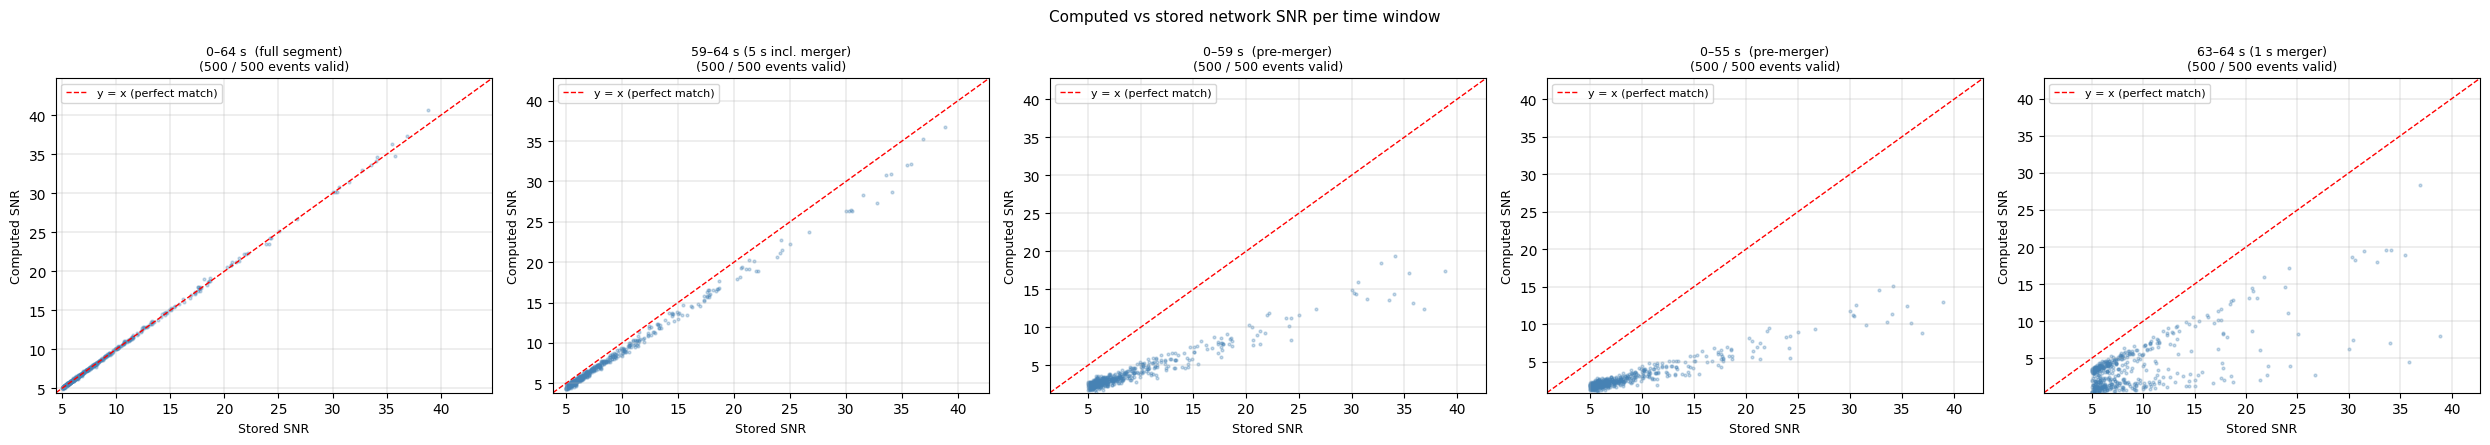

In [22]:
# ── Scatter: computed SNR vs stored SNR ──────────────────────────────────────
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(5 * len(WINDOWS), 4.5))

for ax, (_, _, label) in zip(axes, WINDOWS):
    snr_computed, snr_stored = results[label]

    # Drop any events where SNR computation failed
    valid = np.isfinite(snr_computed) & np.isfinite(snr_stored)
    snr_c = snr_computed[valid]
    snr_s = snr_stored[valid]

    lo = min(snr_c.min(), snr_s.min()) * 0.9
    hi = max(snr_c.max(), snr_s.max()) * 1.1

    ax.scatter(snr_s, snr_c, s=4, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.0, label='y = x (perfect match)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Stored SNR', fontsize=9)
    ax.set_ylabel('Computed SNR', fontsize=9)
    ax.set_title(f"{label}\n({valid.sum()} / {len(valid)} events valid)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('Computed vs stored network SNR per time window', fontsize=11)
plt.tight_layout()
plt.show()

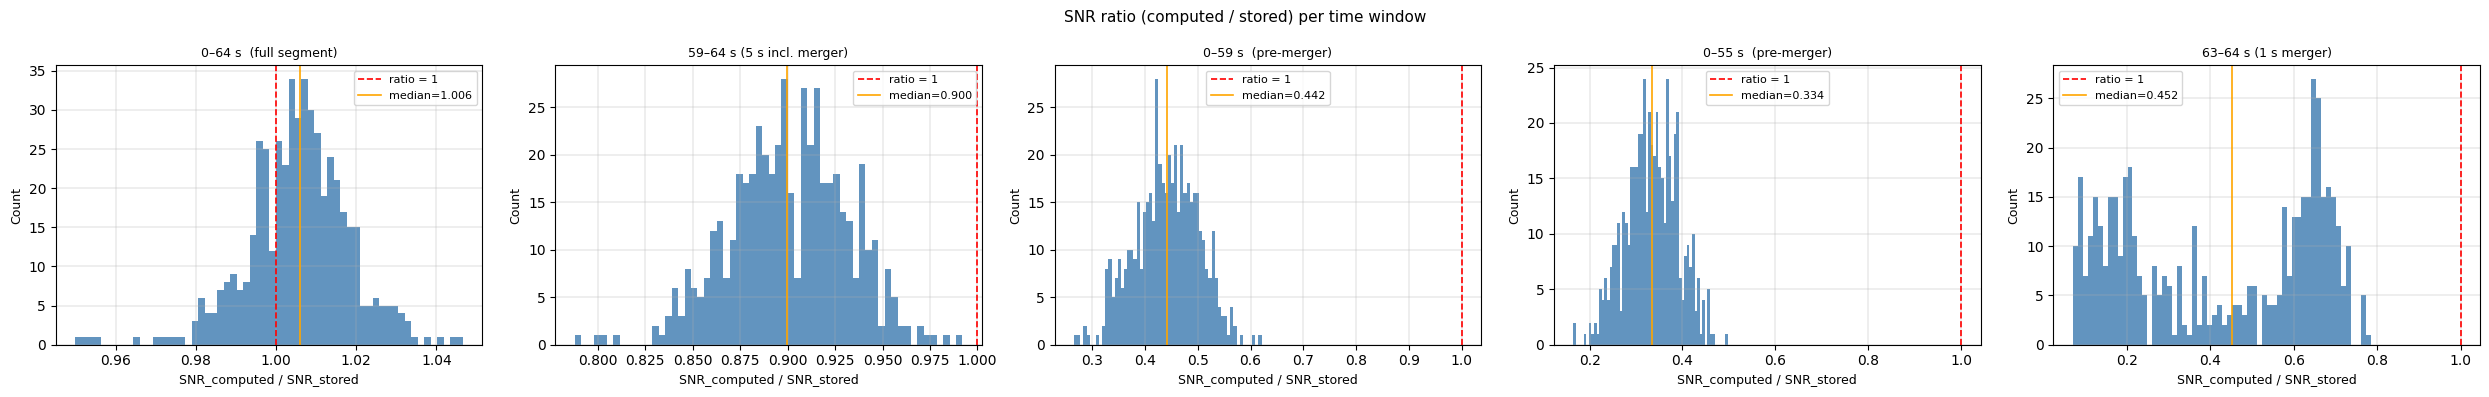

In [23]:
# ── Histogram: ratio (computed / stored) per window ──────────────────────────
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(5 * len(WINDOWS), 4))

for ax, (_, _, label) in zip(axes, WINDOWS):
    snr_c, snr_s = results[label]
    ratio = snr_c / snr_s

    ax.hist(ratio, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(1.0, color='red', lw=1.2, ls='--', label='ratio = 1')
    ax.axvline(np.median(ratio), color='orange', lw=1.2, ls='-',
               label=f'median={np.median(ratio):.3f}')
    ax.set_xlabel('SNR_computed / SNR_stored', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('SNR ratio (computed / stored) per time window', fontsize=11)
plt.tight_layout()
plt.show()

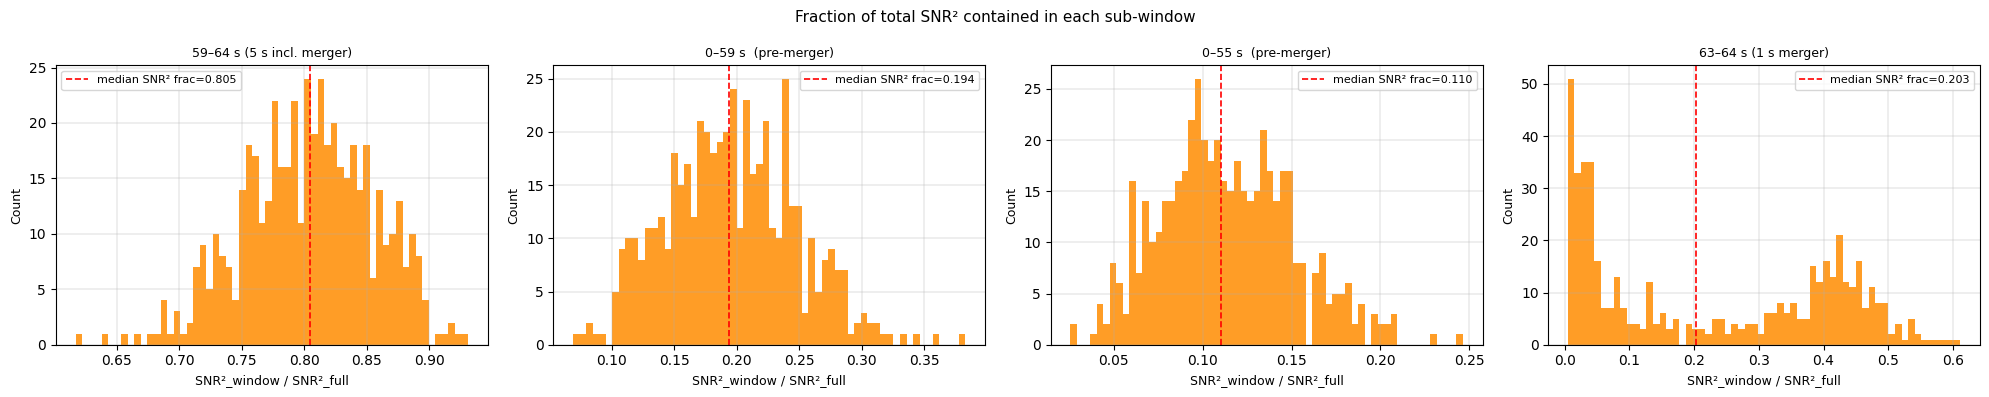

In [24]:
# ── SNR fraction: what fraction of total SNR is in each sub-window? ───────────
# Compare computed SNR in each sub-window to the full-segment computed SNR.
label_full = WINDOWS[0][2]  # "0–64 s (full segment)"
snr_full   = results[label_full][0]

fig, axes = plt.subplots(1, len(WINDOWS) - 1, figsize=(5 * (len(WINDOWS) - 1), 4))

for ax, (_, _, label) in zip(axes, WINDOWS[1:]):
    snr_c  = results[label][0]
    # SNR adds in quadrature, so fraction of SNR^2
    frac   = (snr_c / snr_full) ** 2

    ax.hist(frac, bins=60, color='darkorange', edgecolor='none', alpha=0.85)
    ax.axvline(np.median(frac), color='red', lw=1.2, ls='--',
               label=f'median SNR² frac={np.median(frac):.3f}')
    ax.set_xlabel('SNR²_window / SNR²_full', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

plt.suptitle('Fraction of total SNR² contained in each sub-window', fontsize=11)
plt.tight_layout()
plt.show()

Loading 200 events at 4096 Hz ...

4096 Hz  (Nyquist = 2048 Hz)
  computed median=6.72  stored median=6.69  ratio=1.006

2048 Hz  (Nyquist = 1024 Hz)
  computed median=5.02  stored median=6.69  ratio=0.750

1024 Hz  (Nyquist = 512 Hz)
  computed median=4.98  stored median=6.69  ratio=0.745

512 Hz  (Nyquist = 256 Hz)
  computed median=4.81  stored median=6.69  ratio=0.718

256 Hz  (Nyquist = 128 Hz)
  computed median=4.22  stored median=6.69  ratio=0.626

128 Hz  (Nyquist = 64 Hz)
  computed median=2.72  stored median=6.69  ratio=0.405

64 Hz  (Nyquist = 32 Hz)
  computed median=0.83  stored median=6.69  ratio=0.119

32 Hz  (Nyquist = 16 Hz)
  computed median=0.00  stored median=6.69  ratio=0.000


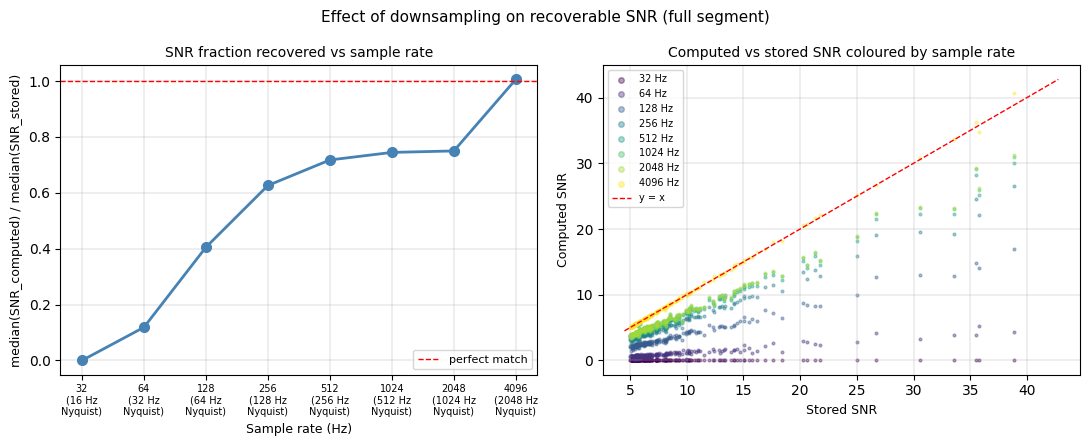

In [25]:
# ── SNR vs downsample rate (full segment, 0–duration s) ───────────────────────
# Downsample whitened_signal and whitened_bkg to each target rate,
# use per-event PSDs, compare computed SNR to stored.
from scipy.signal import resample_poly
from math import gcd

# Powers of 2 down from SAMPLE_RATE
DOWNSAMPLE_RATES = [SAMPLE_RATE // (2**i)
                    for i in range(int(np.log2(SAMPLE_RATE // 32)) + 1)]
N_DS_EVENTS = min(200, N_EVENTS or 1000)

def _resample(arr, orig_sr, target_sr):
    """Anti-aliasing resample along last axis."""
    if orig_sr == target_sr:
        return arr
    g = gcd(int(orig_sr), int(target_sr))
    return resample_poly(arr, target_sr // g, orig_sr // g, axis=-1)

# Load full-segment data once at native rate
print(f"Loading {N_DS_EVENTS} events at {SAMPLE_RATE} Hz ...")
with h5py.File(H5_PATH, 'r') as f:
    sig_native     = f['whitened_signal'][:N_DS_EVENTS]
    bkg_native     = f['whitened_bkg'][:N_DS_EVENTS]
    snr_stored_ds  = f['snr'][:N_DS_EVENTS].astype(np.float64)

ds_results = {}   # target_sr -> (snr_computed, median_ratio)

for target_sr in DOWNSAMPLE_RATES:
    print(f"\n{target_sr} Hz  (Nyquist = {target_sr//2} Hz)")

    sig_ds = _resample(sig_native, SAMPLE_RATE, target_sr).astype(np.float64)
    bkg_ds = _resample(bkg_native, SAMPLE_RATE, target_sr).astype(np.float64)

    sd_ds       = SpectralDensity(sample_rate=target_sr, fftlength=FFTLENGTH, average=AVERAGE)
    n_psd_bins  = sig_ds.shape[-1] // 2 + 1

    snr_chunks = []
    for s in range(0, N_DS_EVENTS, BATCH_SIZE):
        e   = min(s + BATCH_SIZE, N_DS_EVENTS)
        psd = sd_ds(torch.tensor(bkg_ds[s:e], dtype=torch.float64))   # (batch, 2, n_fft_bins)
        psd_w = F.interpolate(psd, size=(n_psd_bins,), mode='linear') # (batch, 2, n_psd_bins)
        with torch.no_grad():
            snr_chunks.append(
                compute_network_snr(
                    torch.tensor(sig_ds[s:e], dtype=torch.float64),
                    psd_w, float(target_sr), float(F_MIN),
                ).numpy()
            )
    snr_c = np.concatenate(snr_chunks)
    ratio = np.nanmedian(snr_c / snr_stored_ds)
    ds_results[target_sr] = (snr_c, ratio)
    print(f"  computed median={np.median(snr_c):.2f}  stored median={np.median(snr_stored_ds):.2f}  ratio={ratio:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
rates  = sorted(ds_results.keys())
ratios = [ds_results[sr][1] for sr in rates]
colors = plt.cm.viridis(np.linspace(0, 1, len(rates)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(rates, ratios, 'o-', color='steelblue', lw=2, ms=7)
ax1.axhline(1.0, color='red', ls='--', lw=1, label='perfect match')
ax1.set_xlabel('Sample rate (Hz)', fontsize=9)
ax1.set_ylabel('median(SNR_computed) / median(SNR_stored)', fontsize=9)
ax1.set_title('SNR fraction recovered vs sample rate', fontsize=10)
ax1.set_xscale('log', base=2)
ax1.set_xticks(rates)
ax1.set_xticklabels([f'{sr}\n({sr//2} Hz\nNyquist)' for sr in rates], fontsize=7)
ax1.legend(fontsize=8); ax1.grid(True, lw=0.3)

for sr, color in zip(rates, colors):
    snr_c = ds_results[sr][0]
    valid = np.isfinite(snr_c) & np.isfinite(snr_stored_ds)
    ax2.scatter(snr_stored_ds[valid], snr_c[valid],
                s=4, alpha=0.4, color=color, label=f'{sr} Hz', rasterized=True)
lo = snr_stored_ds.min() * 0.9
hi = snr_stored_ds.max() * 1.1
ax2.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y = x')
ax2.set_xlabel('Stored SNR', fontsize=9)
ax2.set_ylabel('Computed SNR', fontsize=9)
ax2.set_title('Computed vs stored SNR coloured by sample rate', fontsize=10)
ax2.legend(fontsize=7, markerscale=2); ax2.grid(True, lw=0.3)

plt.suptitle('Effect of downsampling on recoverable SNR (full segment)', fontsize=11)
plt.tight_layout()
plt.show()